# Employee Attrition Analysis & Prediction

#### Author: **Michael de Lorenzo**

<br>

## *Executive Summary*
This project aims to identify the key drivers of employee turnover (attrition) and build a predictive model to help HR departments take proactive measures.

<ul style="line-height: 2.0;">

* **Problem:** High employee turnover is costly. We need to understand why employees leave.

* **Approach:** I conducted an Exploratory Data Analysis (EDA) on HR data, performed Feature Engineering, and trained a Weighted Decision Tree classifier.

* **Key Finding:** Overtime, low tenure (< 2 years), and specific income thresholds are the strongest predictors of resignation.

* **Result:** The final model achieves a *Recall of ~55%* for the "Attrition" class, successfully identifying the majority of at-risk employees.
</ul>

<br>

## 1. Introduction & Data Loading

<br>

In [73]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
# Loading the data set
df = pd.read_csv('../data/Hr-Employee-Attrition.csv')

In [75]:
# Get an overview of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [76]:
# Displaying the first 5 rows of the data
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [77]:
# Count of unique values in each column
print(df.nunique())

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [78]:
# Filtering and dropping columns less relevant for the analysis
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

In [79]:
# Output column count of updated dataframe for verification
print(f"Remaining columns in the dataset: {df.shape[1]}")

Remaining columns in the dataset: 31


<br>

-------------------

<br>

## 2. Exploratory Data Analysis (EDA)

<br>

### 2.1 Distribution of Key Features

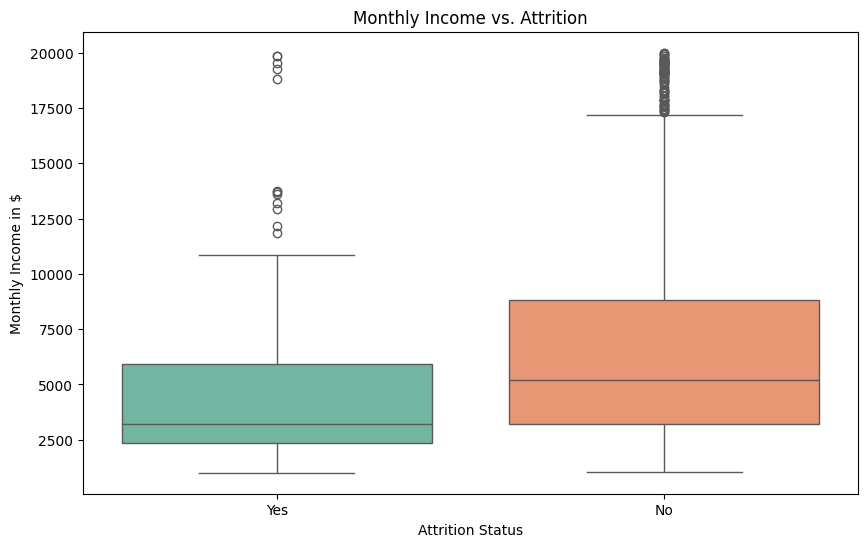

In [80]:
# Boxplot visualization to investigate the relationship between attrition and income
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='Set2', legend=False)
plt.xticks([1, 0], ['No', 'Yes'])
plt.title('Monthly Income vs. Attrition')
plt.xlabel('Attrition Status')
plt.ylabel('Monthly Income in $')
plt.show()

# Monthly Income as a Key Driver

The boxplot visualization reveals a clear relationship between compensation and employee attrition.

1. Lower Median Income: Employees who left the company (Yes) show a significantly lower median monthly income compared to those who stayed. This suggests that financial compensation is a primary factor in retention.

2. Higher Density at Lower Levels: The interquartile range (the box) for the "Yes" group is positioned notably lower on the income scale.

3. High-Income Outliers: Interestingly, there are several outliers in the "Yes" group. This indicates that while salary is crucial, high-earners also resign, likely due to other factors such as work-life balance, career growth, or organizational culture.

<br>

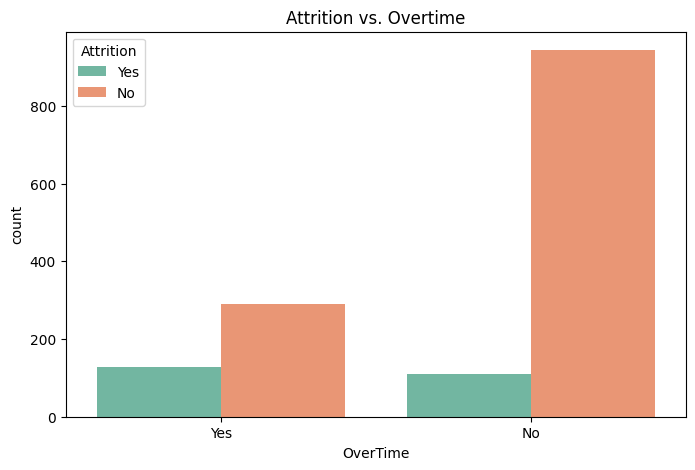

In [81]:
# Are working hours a reason for termination? Visualization in the form of a bar chart

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2')
plt.xticks([1, 0], ['No', 'Yes'])
plt.title('Attrition vs. Overtime')
plt.show()

# The Critical Role of Overtime

The comparison of overtime work and attrition reveals a significant disparity:

1. High Relative Turnover: For employees working overtime ("Yes"), the ratio between staying and leaving is much narrower. A substantially higher percentage of this group chooses to resign.

2. Low Risk without Overtime: In contrast, for employees with "No Overtime", the vast majority remains with the company, with only a very small fraction leaving.

3. Strategic Takeaway: Overtime appears to be one of the most reliable "red flags" for attrition. Reducing excessive workload or implementing better compensation for extra hours could be a highly effective retention strategy.

<br>

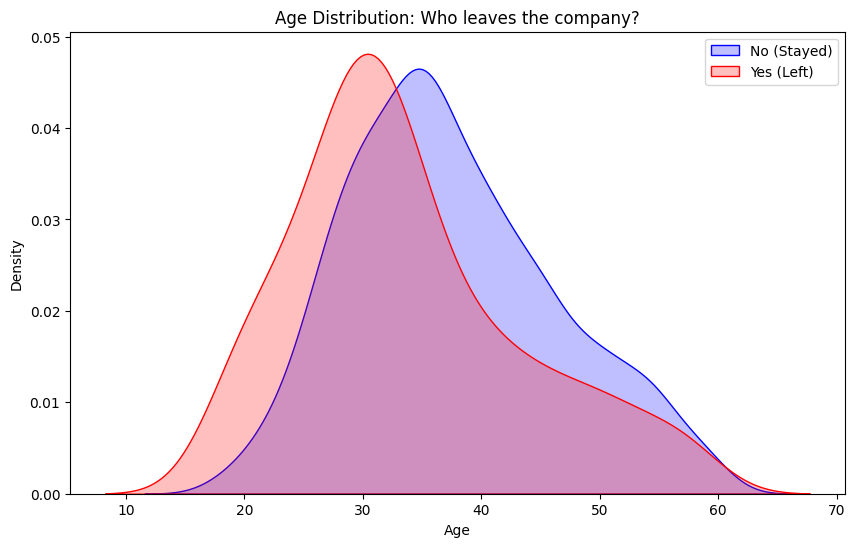

In [91]:
# Analyzing if attrition affects new hires or long-tenured employees

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['Attrition'] == 0]['Age'], label='No (Stayed)', fill=True, color='blue')
sns.kdeplot(data=df[df['Attrition'] == 1]['Age'], label='Yes (Left)', fill=True, color='red')

plt.title('Age Distribution: Who leaves the company?')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

### Age as a Factor for Stability

The Kernel Density Estimate (KDE) plot visualizes the distribution of age across both groups:

1. Youth Attrition: The "Yes" curve (red) shows a prominent peak between the ages of 25 and 35. This suggests that younger professionals are more likely to seek new opportunities or career changes.

2. Seniority & Retention: As employees get older, the probability of attrition decreases significantly. The blue curve (stayed) is much broader, indicating that older employees value stability and are less likely to leave.

3. Strategic Takeaway: HR should focus its retention programs - such as mentoring or clearer career paths - specifically on the "Early Career" segment to reduce this early - stage turnover.


<br>

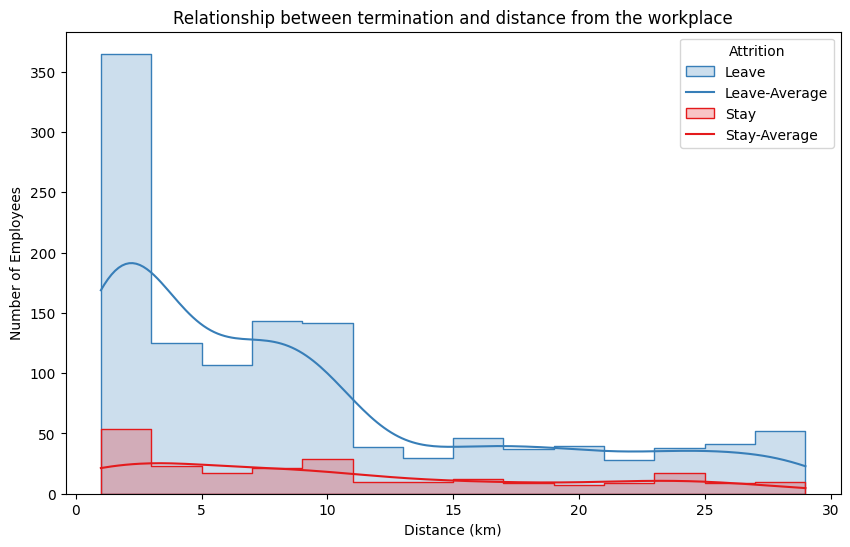

In [83]:
# Histogram illustrating the relationship between termination and distance from the workplace

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', kde=True, element="step", palette='Set1')
plt.title('Relationship between termination and distance from the workplace')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition', labels=['Leave', 'Leave-Average', 'Stay', 'Stay-Average'])
plt.show()

### The Impact of Commuting Distance

The histogram illustrates how the distance from home correlates with employee turnover:

1. Proximity Breeds Loyalty: Employees living close to the office show a very low attrition rate. The "Stayed" group is dominant at shorter distances.

2. The Distance Threshold: As the distance increases, the ratio of resignations compared to staying employees rises significantly.

3. Strategic Takeaway: Long commutes appear to be a major "pain point." To improve retention for distant employees, HR could consider offering flexible remote work options or travel subsidies to mitigate the impact of the daily commute.

<br>

-----------------------------

<br>

## 3. Data Preprocessing & Feature Engineering

<br>

### 3.1 Handling Categorical Variables (One-Hot Encoding)

In [84]:
# Converting categorical data (Yes/No) to binary data (0/1) for further use

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print(df[['Attrition', 'OverTime']].head())

   Attrition  OverTime
0          1         1
1          0         0
2          1         1
3          0         1
4          0         0


In [85]:
# Selection of features that are significant for the model and have already been identified during exploratory data analysis

feature_cols = [
    'Age', 'MonthlyIncome', 'OverTime', 'DistanceFromHome', 
    'JobSatisfaction', 'TotalWorkingYears', 'BusinessTravel', 'Department'
]

# Dataframe with important Columns for the Prediction
X = df[feature_cols].copy()

# Create dummies for "BusinessTravel" and "Department" in order to transform categorial data with different values into binary data to analyze
X = pd.get_dummies(X, columns=['BusinessTravel', 'Department'], drop_first=True)

# Define the target which will be predicted
y = df['Attrition']

# Overview of the results
X.head()

,Age,MonthlyIncome,OverTime,DistanceFromHome,JobSatisfaction,TotalWorkingYears,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales
0,41,5993,1,1,4,8,False,True,False,True
1,49,5130,0,8,2,10,True,False,True,False
2,37,2090,1,2,3,7,False,True,True,False
3,33,2909,1,3,3,8,True,False,True,False
4,27,3468,0,2,2,6,False,True,True,False


<br>

### 3.2 Train-Test Split

In [86]:
# Separating into Training-Data and Test-Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # 20% is Test-Data and 80% are used as Training-Data
    random_state=20, # Ensures reproducibility of the split for consistent results
    stratify=y # Maintains the original class distribution (Stayed vs. Left) in both sets
)

print(f"Training (80%): {X_train.shape[0]} Employees")
print(f"Test (20%): {X_test.shape[0]} Employees")

Training (80%): 1176 Employees
Test (20%): 294 Employees


<br>

-------------------------------

<br>

## 4. Machine Learning Modeling

In [87]:
from sklearn.tree import DecisionTreeClassifier

# Initializing the Decision Tree Classifier
# max_depth=3 limits tree depth to 3 levels to prevent overfitting and ensure interpretability
# Penalizes misclassification of the minority class (attrition) more heavily
clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')

# Model with Training-Data
clf.fit(X_train, y_train)

print("Training done...")

Training done...


<br>

### 4.1 Decision Tree with Class Balancing

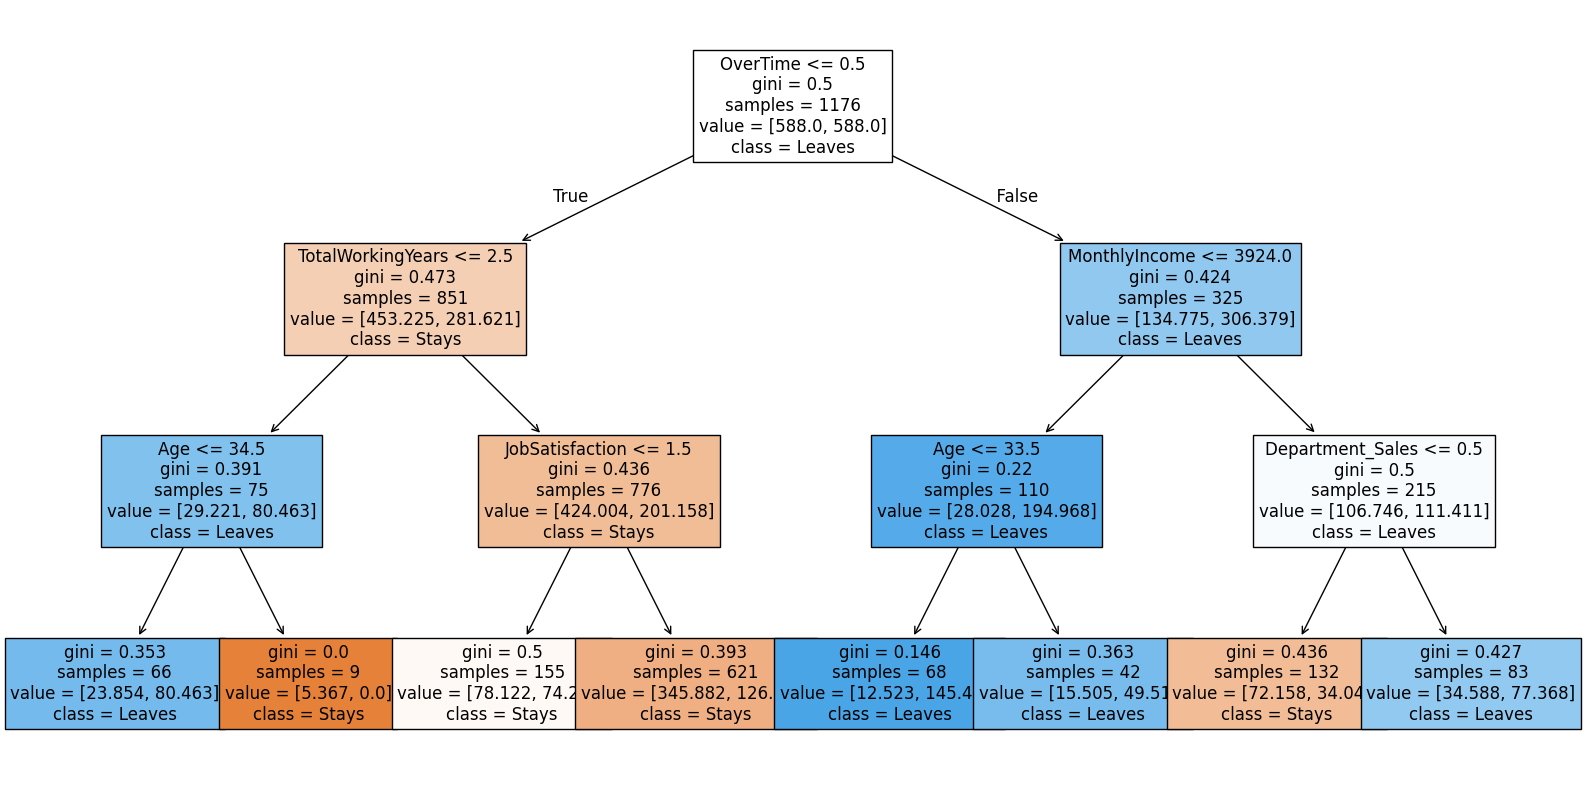

In [88]:
# Visualization of "Decision Tree" to understand how the model values the different features
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['Stays', 'Leaves'], 
          filled=True, 
          fontsize=12)
plt.show()

# Decision Logic

The Decision Tree identifies "OverTime" as the primary splitting criterion (Root Node), confirming that workload is the most immediate predictor of attrition.

1. The Overtime Factor: The model first separates employees based on whether they work overtime. This aligns with the EDA finding that extra hours represent a critical "red flag".

2. Tenure & Stability: For employees without overtime, the model sets a secondary threshold at 2.5 years of TotalWorkingYears. This indicates that early-career staff remain a high-risk group even without excessive workloads.

3. Income & Role Refinement: For those working overtime, the model incorporates MonthlyIncome (threshold ~$3,924) and Department (Sales) to refine its predictions. Lower-income earners and Sales staff within the overtime group show the highest propensity to leave.

**Key Takeaway:** The analysis reveals a dual-risk structure. While overtime is the leading catalyst, the first 30 months of employment (Tenure <= 2.5) constitute the most critical phase for targeted retention efforts.

<br>

### 4.2 Model Evaluation (Confusion Matrix & Accuracy)

In [89]:
# Making predictions based on Test-Data
y_pred = clf.predict(X_test)

# Calculating the Accuracy of the Model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f"The Model detects in {round(accuracy*100, 2)}% of the cases the right situation.")

The Model detects in 77.89% of the cases the right situation.


An initial Accuracy of 77.89% might seem strong at first glance. However, in an imbalanced dataset, accuracy can be a misleading metric.
To gain a deeper understanding of the model's performance, I implemented a Confusion Matrix.

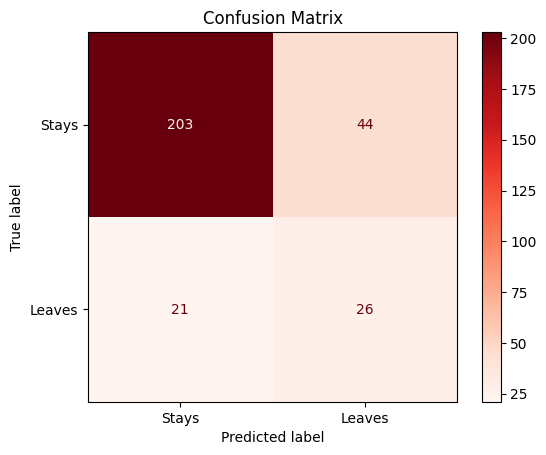

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stays', 'Leaves'])
disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Analysis
The confusion matrix highlights the effectiveness of the balanced class weights:

1. Proactive Detection: The model successfully identified 26 out of 47 actual resignations (55% Recall). This ensures that more than half of at-risk employees are flagged for retention talks.

2. The Trade-off: To prioritize employee retention, the model is intentionally sensitive, resulting in 44 False Alarms. In HR practice, this "over-detection" is preferred, as the cost of losing a key employee far outweighs the cost of a preventive conversation.

3. Overall Reliability: With 203 correctly identified "Stayers", the model maintains a solid baseline for overall workforce stability.